In [3]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules
import matplotlib.pyplot as plt
import seaborn as sb
import arabic_reshaper
from bidi.algorithm import get_display

In [4]:
store_data = pd.read_excel("Egyptian_Grocery_Transactions.xlsx",header=None)  #load dataset

In [5]:
store_data

,0
0,"سكر,لبن,شاي"
1,"فراخ,بطاطس"
2,"رز,فراخ"
3,"عسل,لحمة,رز,زبادي"
4,"بصل,رز,عدس"
5,"شيبسي,فلفل,بيبسي,مياه"
6,"فراخ,بطاطس,شيبسي"
7,"طماطم,عدس,كورن فليكس"
8,"عسل,مربة,زيت,عيش بلدي"
9,"فراخ,مكرونة,شاي,كشري,سكر,سمنة"


In [6]:
store_data.values.tolist()

    

[['سكر,لبن,شاي'],
 ['فراخ,بطاطس'],
 ['رز,فراخ'],
 ['عسل,لحمة,رز,زبادي'],
 ['بصل,رز,عدس'],
 ['شيبسي,فلفل,بيبسي,مياه'],
 ['فراخ,بطاطس,شيبسي'],
 ['طماطم,عدس,كورن فليكس'],
 ['عسل,مربة,زيت,عيش بلدي'],
 ['فراخ,مكرونة,شاي,كشري,سكر,سمنة'],
 ['عسل,عدس'],
 ['زيت,بيض,فول,مكرونة,صلصة,جبنة قريش'],
 ['شاي,عدس,عسل,زيت,بيبسي,بيض'],
 ['رز,عدس,كشري'],
 ['كشري,عيش بلدي'],
 ['لبن,بيبسي,مربة'],
 ['سكر,عيش بلدي,مكرونة'],
 ['بيبسي,زبادي,طعمية'],
 ['بيبسي,سكر,زيت,عدس,فول,بيض'],
 ['بيض,بيبسي,طعمية,سكر,سمنة,جبنة قريش']]

In [7]:
transactions = []
for i in range(len(store_data)):
    transactions.append(store_data.values[i,0].split(","))

In [8]:
transactions

[['سكر', 'لبن', 'شاي'],
 ['فراخ', 'بطاطس'],
 ['رز', 'فراخ'],
 ['عسل', 'لحمة', 'رز', 'زبادي'],
 ['بصل', 'رز', 'عدس'],
 ['شيبسي', 'فلفل', 'بيبسي', 'مياه'],
 ['فراخ', 'بطاطس', 'شيبسي'],
 ['طماطم', 'عدس', 'كورن فليكس'],
 ['عسل', 'مربة', 'زيت', 'عيش بلدي'],
 ['فراخ', 'مكرونة', 'شاي', 'كشري', 'سكر', 'سمنة'],
 ['عسل', 'عدس'],
 ['زيت', 'بيض', 'فول', 'مكرونة', 'صلصة', 'جبنة قريش'],
 ['شاي', 'عدس', 'عسل', 'زيت', 'بيبسي', 'بيض'],
 ['رز', 'عدس', 'كشري'],
 ['كشري', 'عيش بلدي'],
 ['لبن', 'بيبسي', 'مربة'],
 ['سكر', 'عيش بلدي', 'مكرونة'],
 ['بيبسي', 'زبادي', 'طعمية'],
 ['بيبسي', 'سكر', 'زيت', 'عدس', 'فول', 'بيض'],
 ['بيض', 'بيبسي', 'طعمية', 'سكر', 'سمنة', 'جبنة قريش']]

In [9]:
encoder = TransactionEncoder() 
tran = encoder.fit(transactions).transform(transactions)

In [10]:
tran

array([[False, False, False, False, False, False, False, False,  True,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True,  True, False, False,
        False, False, False, False, False, False, False,  True, False,
        False, False, False, False, False, False,  True, False, False,
        False],
       [ True, False, False, False, False,  True, False, False, False,
        False

In [11]:
encoded_data = pd.DataFrame(data = tran, columns = encoder.columns_, dtype = int)
encoded_data.head(4)

,بصل,بطاطس,بيبسي,بيض,جبنة قريش,رز,زبادي,زيت,سكر,سمنة,...,فراخ,فلفل,فول,كشري,كورن فليكس,لبن,لحمة,مربة,مكرونة,مياه
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [12]:
encoded_data

,بصل,بطاطس,بيبسي,بيض,جبنة قريش,رز,زبادي,زيت,سكر,سمنة,...,فراخ,فلفل,فول,كشري,كورن فليكس,لبن,لحمة,مربة,مكرونة,مياه
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
6,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0,0,0,0,0,0,0,0,1,1,...,1,0,0,1,0,0,0,0,1,0


In [13]:
frequent_items = apriori(encoded_data,min_support=0.1,use_colnames=True)
frequent_items.sort_values(by = 'support', ascending = False)

C:\Users\START\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
12,0.30,(عدس)
1,0.30,(بيبسي)
7,0.25,(سكر)
15,0.20,(فراخ)
2,0.20,(بيض)
4,0.20,(رز)
6,0.20,(زيت)
13,0.20,(عسل)
17,0.15,(كشري)
22,0.15,"(بيبسي, بيض)"


In [14]:
rules = association_rules(frequent_items, metric = 'confidence', min_threshold = 0.3)

In [15]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(بطاطس),(فراخ),0.1,0.20,0.10,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
1,(فراخ),(بطاطس),0.2,0.10,0.10,0.500000,5.000000,1.0,0.080,1.80,1.000000,0.500000,0.444444,0.750000
2,(بيبسي),(بيض),0.3,0.20,0.15,0.500000,2.500000,1.0,0.090,1.60,0.857143,0.428571,0.375000,0.625000
3,(بيض),(بيبسي),0.2,0.30,0.15,0.750000,2.500000,1.0,0.090,2.80,0.750000,0.428571,0.642857,0.625000
4,(بيبسي),(زيت),0.3,0.20,0.10,0.333333,1.666667,1.0,0.040,1.20,0.571429,0.250000,0.166667,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,"(زيت, عدس)","(بيبسي, بيض)",0.1,0.15,0.10,1.000000,6.666667,1.0,0.085,inf,0.944444,0.666667,1.000000,0.833333
84,(بيبسي),"(بيض, زيت, عدس)",0.3,0.10,0.10,0.333333,3.333333,1.0,0.070,1.35,1.000000,0.333333,0.259259,0.666667
85,(بيض),"(بيبسي, زيت, عدس)",0.2,0.10,0.10,0.500000,5.000000,1.0,0.080,1.80,1.000000,0.500000,0.444444,0.750000
86,(زيت),"(بيبسي, بيض, عدس)",0.2,0.10,0.10,0.500000,5.000000,1.0,0.080,1.80,1.000000,0.500000,0.444444,0.750000


In [16]:
rules.sort_values(by = 'confidence', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(بطاطس),(فراخ),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
69,"(بيض, فول)",(زيت),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
39,"(بيبسي, زيت)",(بيض),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
46,"(سكر, بيض)",(بيبسي),0.1,0.30,0.1,1.000000,3.333333,1.0,0.070,inf,0.777778,0.333333,1.000000,0.666667
51,"(بيبسي, عدس)",(بيض),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,(بيبسي),"(زيت, عدس)",0.3,0.10,0.1,0.333333,3.333333,1.0,0.070,1.350,1.000000,0.333333,0.259259,0.666667
19,(عدس),(بيض),0.3,0.20,0.1,0.333333,1.666667,1.0,0.040,1.200,0.571429,0.250000,0.166667,0.416667
25,(عدس),(زيت),0.3,0.20,0.1,0.333333,1.666667,1.0,0.040,1.200,0.571429,0.250000,0.166667,0.416667
55,(عدس),"(بيبسي, بيض)",0.3,0.15,0.1,0.333333,2.222222,1.0,0.055,1.275,0.785714,0.285714,0.215686,0.500000


Text(0.5, 1.0, 'Top Rules')

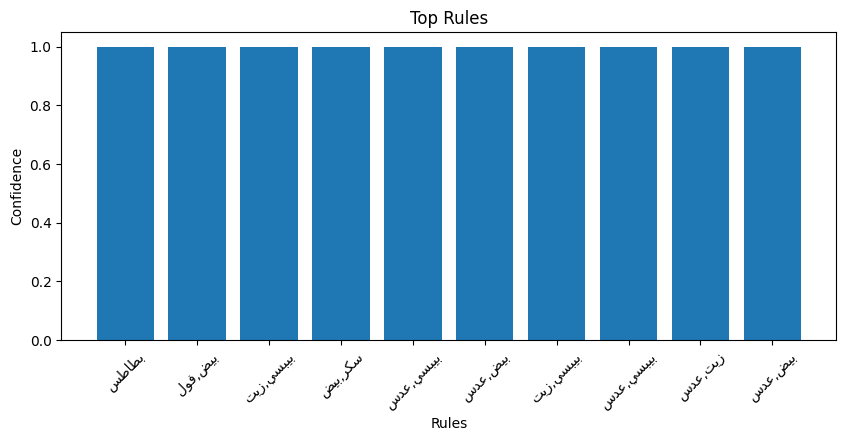

In [22]:
top_rules = rules.sort_values(by='confidence', ascending=False).head(10)

plt.figure(figsize=(10,4))
plt.bar(range(len(top_rules)), top_rules['confidence'])

labels = []
for item in top_rules['antecedents']:
    text = ','.join(list(item))
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    labels.append(bidi_text)

plt.xticks(range(len(top_rules)), labels, rotation=45)

plt.xlabel("Rules")
plt.ylabel("Confidence")
plt.title("Top Rules")